# 13. Convergence Monitor и phase-aware personalization loop

Цель ноутбука — добавить в контур персонализации маркеры сходимости и проверить, можно ли технически определить момент, когда система уже поймала направление предпочтений пользователя.

В этом эксперименте сравниваются два режима:

1. `Semantic active v3 fixed` — текущий основной Pair Generator, который все шаги использует semantic-active вопросы.
2. `Phase-aware controller` — контур, который сначала ищет глобальное направление, затем при достаточной уверенности переходит к локальному уточнению зон.

Статусы сессии:

- `exploration` — система ещё ищет направление вкуса;
- `direction_locked` — heuristic state и Preference Model согласованы по направлению;
- `zone_refinement` — система уточняет отдельные зоны вместо крупных semantic-фильтров;
- `ready_to_finalize` — профиль можно считать достаточно стабильным;
- `saturated` — система упёрлась в ограничения compact-вектора / safety bounds.


In [1]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys
import importlib.util

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization.phase_controller import (
    PHASE_DISPLAY_NAMES,
    PhaseControllerConfig,
    run_phase_controller_batch,
    summarize_phase_results,
)
use_article_style()

plot_module_path = PROJECT_ROOT / "experiments" / "13_convergence_phase_controller.py"
spec = importlib.util.spec_from_file_location("phase_plots", plot_module_path)
phase_plots = importlib.util.module_from_spec(spec)
spec.loader.exec_module(phase_plots)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
})


## 1. Загрузка fixed synthetic user dataset

Для быстрого прогона можно ограничить число пользователей на режим через `SAMPLE_PER_MODE`. Для финальных таблиц можно поставить `None` и прогнать полный dataset.


In [2]:
DATASET_PATH = PROJECT_ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
SAMPLE_PER_MODE = 50  # поставь None, чтобы использовать весь dataset

full_dataset = pd.read_csv(DATASET_PATH)

if SAMPLE_PER_MODE is None:
    dataset = full_dataset.copy()
else:
    dataset = (
        full_dataset
        .groupby("target_mode", group_keys=False)
        .head(int(SAMPLE_PER_MODE))
        .reset_index(drop=True)
    )

dataset["target_mode"].value_counts()


target_mode
random8d       50
semantic4d     50
semantic6d     50
archetype8d    50
Name: count, dtype: int64

## 2. Запуск phase-aware эксперимента

`Phase-aware controller` сначала использует `Semantic active v3`, а после фиксации направления переключается на локальные zone-refinement вопросы.


In [3]:
config = PhaseControllerConfig(
    min_lock_step=16,
    lock_confidence_threshold=0.90,
    ready_confidence_threshold=0.88,
    ready_update_norm_threshold=0.32,
    ready_mean_std_threshold=0.25,
    distance_threshold=0.40,
)

sessions_df, steps_df, statuses_df = run_phase_controller_batch(
    dataset=dataset,
    n_steps=25,
    config=config,
)

summary_df = summarize_phase_results(sessions_df)
summary_df


,target_mode,strategy,users,mean_heuristic_final_distance,mean_selected_blend_final_distance,mean_best_distance,mean_distance_auc,direction_lock_rate,ready_rate,synthetic_convergence_rate,saturation_rate,mean_direction_lock_step,mean_ready_step,mean_synthetic_threshold_step,mean_final_direction_confidence
0,archetype8d,phase_aware_v1,50,0.382190,0.362391,0.291288,0.591805,1.0,0.90,0.84,0.0,16.04,18.444444,8.714286,0.953317
1,archetype8d,semantic_active_v3_fixed,50,0.375143,0.358325,0.275170,0.592677,0.0,0.00,0.84,0.0,NaN,NaN,9.214286,0.964740
2,random8d,phase_aware_v1,50,1.378233,1.392761,1.352189,1.649199,1.0,0.90,0.00,0.0,16.02,19.288889,NaN,0.971483
3,random8d,semantic_active_v3_fixed,50,1.422696,1.429698,1.384561,1.659306,0.0,0.00,0.00,0.0,NaN,NaN,NaN,0.983611
4,semantic4d,phase_aware_v1,50,0.436302,0.435520,0.371626,0.852526,1.0,0.94,0.56,0.0,16.00,19.319149,12.107143,0.979727
5,semantic4d,semantic_active_v3_fixed,50,0.413593,0.409328,0.328845,0.854369,0.0,0.00,0.70,0.0,NaN,NaN,14.028571,0.984611
6,semantic6d,phase_aware_v1,50,0.617329,0.619230,0.551320,1.217329,1.0,0.78,0.42,0.0,16.00,20.076923,15.047619,0.983461
7,semantic6d,semantic_active_v3_fixed,50,0.531730,0.537860,0.483911,1.211080,0.0,0.00,0.58,0.0,NaN,NaN,16.586207,0.985971


## 3. Сходимость на Archetype 8D

Этот график показывает, даёт ли phase-aware переключение выигрыш по траектории сходимости относительно фиксированного `Semantic active v3`.


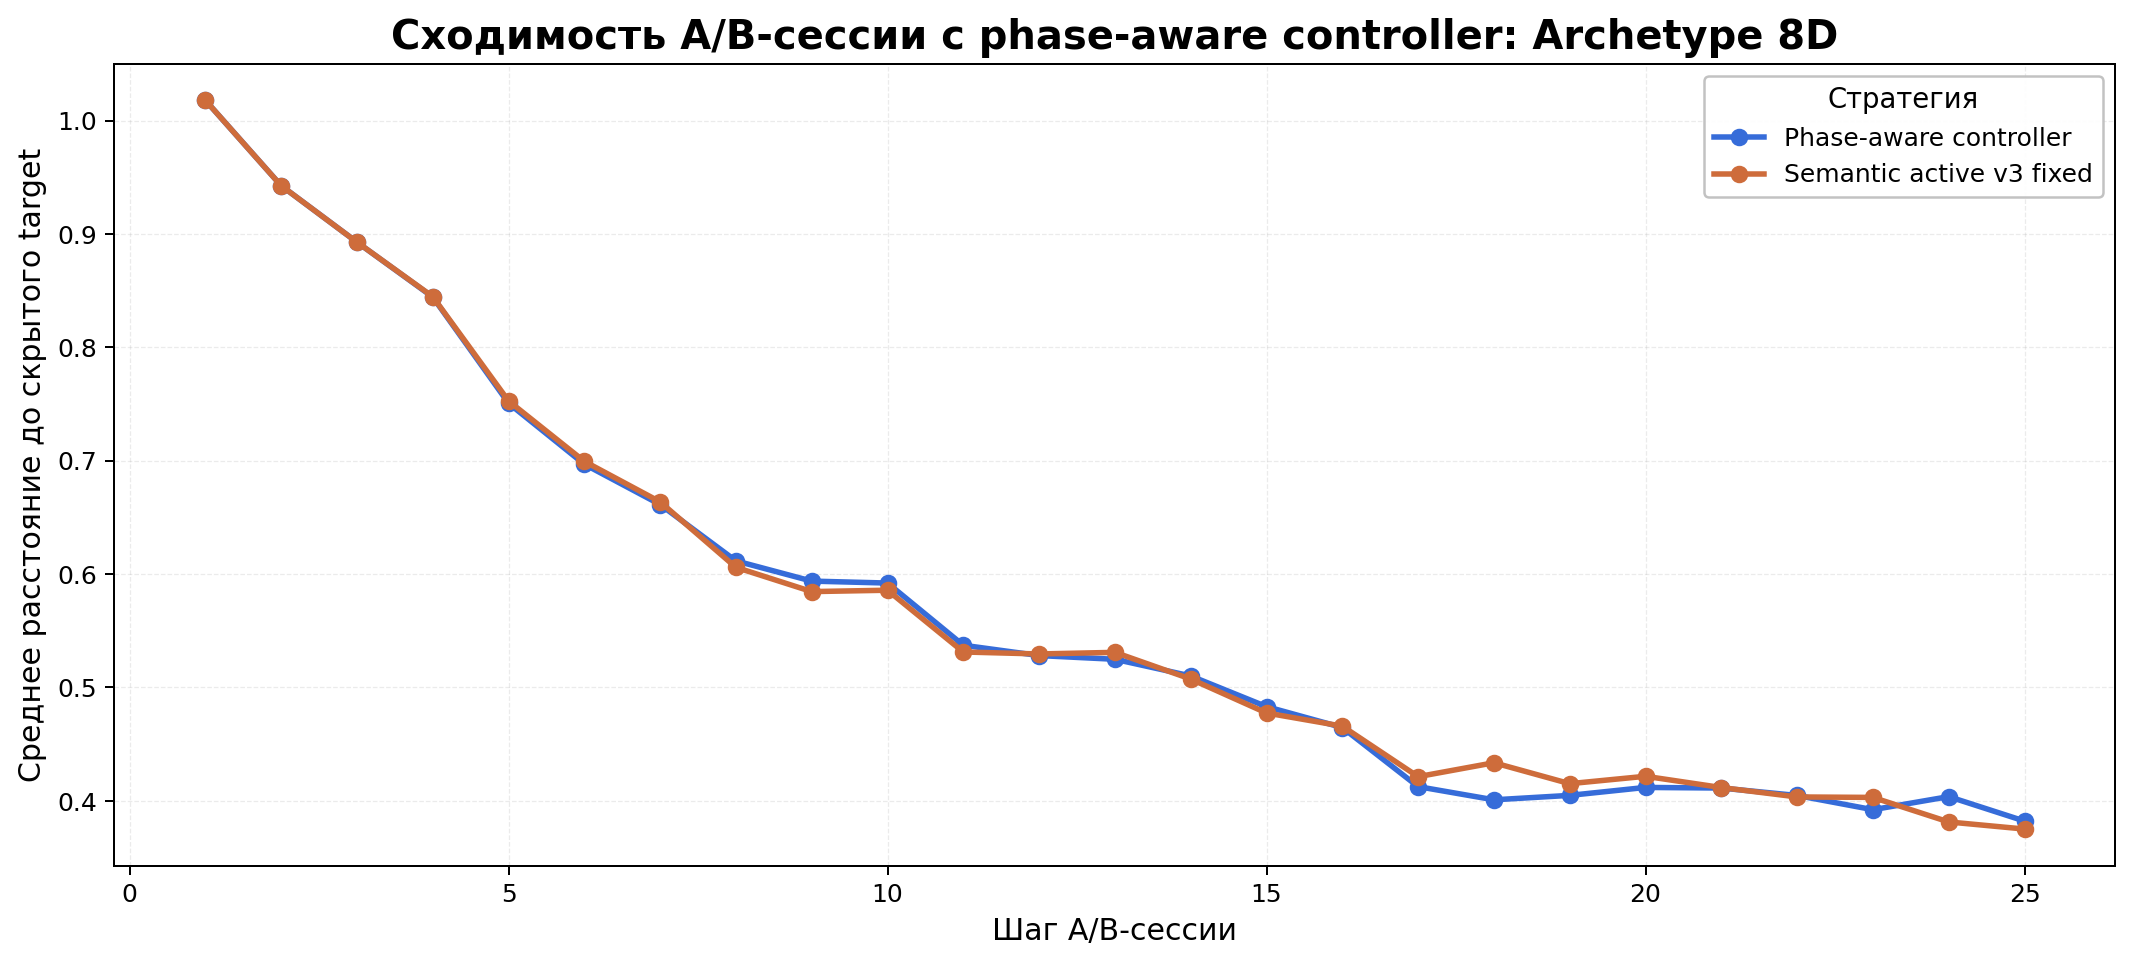

In [4]:
figures_dir = PROJECT_ROOT / "outputs" / "figures"
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
tables_dir = PROJECT_ROOT / "outputs" / "tables"
for d in [figures_dir, metrics_dir, tables_dir]:
    d.mkdir(parents=True, exist_ok=True)

phase_plots.plot_convergence_archetype(
    steps_df,
    figures_dir / "article_phase_controller_convergence_archetype8d.png",
)
from IPython.display import Image, display

display(Image(filename=str(figures_dir / "article_phase_controller_convergence_archetype8d.png")))


## 4. Final distance на Archetype 8D

Здесь сравнивается итоговое расстояние до скрытого target для фиксированной стратегии и phase-aware контура.


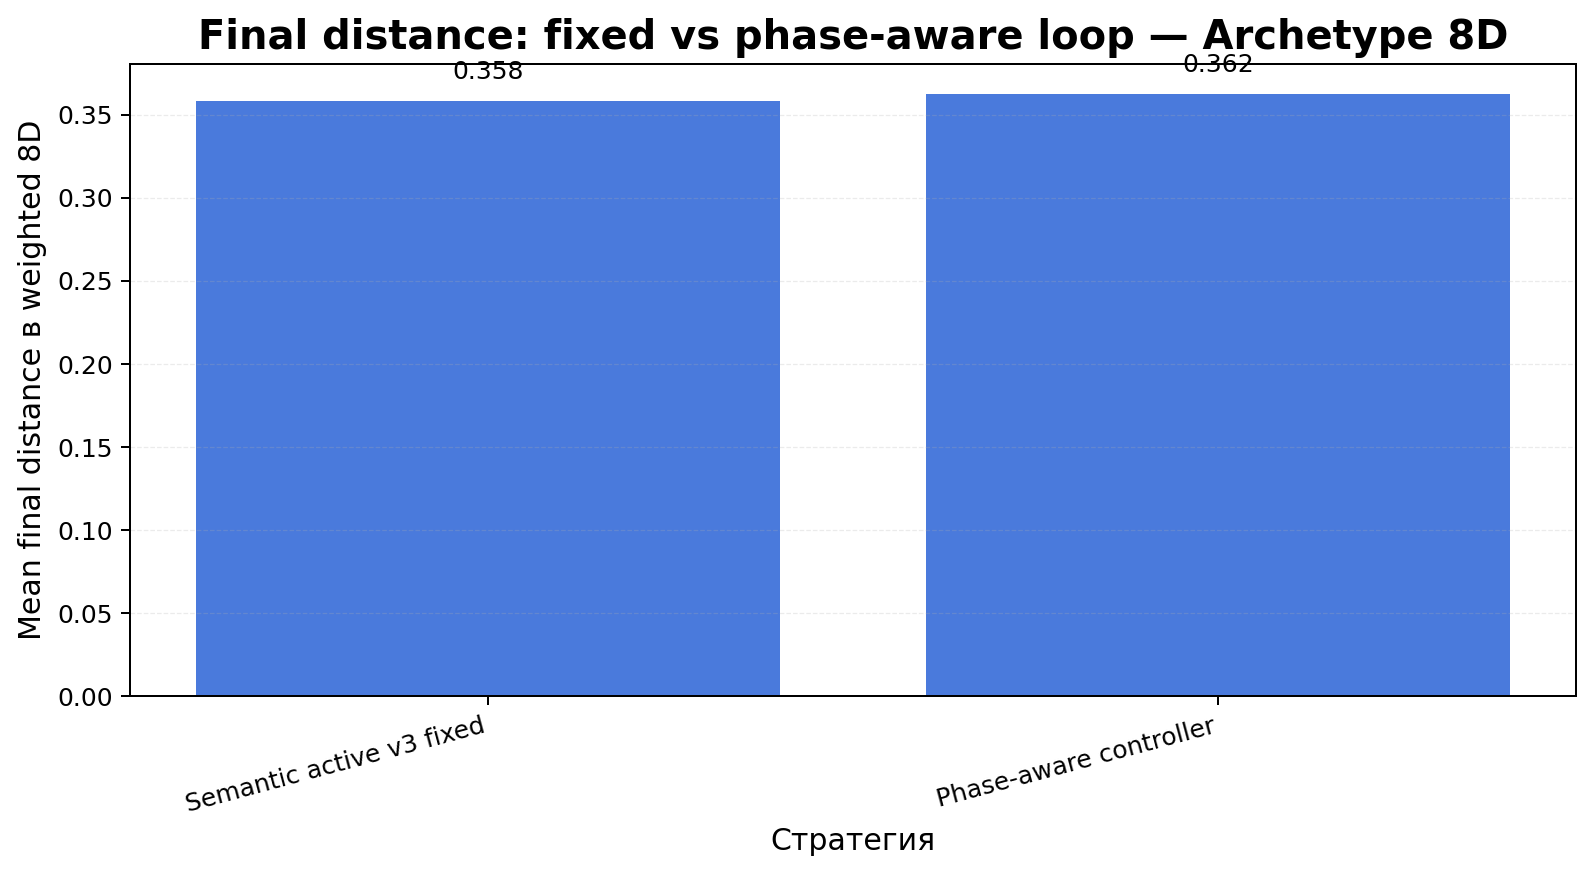

In [5]:
phase_plots.plot_final_distance_archetype(
    sessions_df,
    figures_dir / "article_phase_controller_final_distance_archetype8d.png",
)
display(Image(filename=str(figures_dir / "article_phase_controller_final_distance_archetype8d.png")))


## 5. Скорость сходимости

Вводятся три маркера:

- `Direction locked` — система поймала направление предпочтений;
- `Ready to finalize` — профиль можно считать технически стабильным;
- `Distance threshold` — synthetic-only маркер, когда расстояние до скрытого target ниже порога.


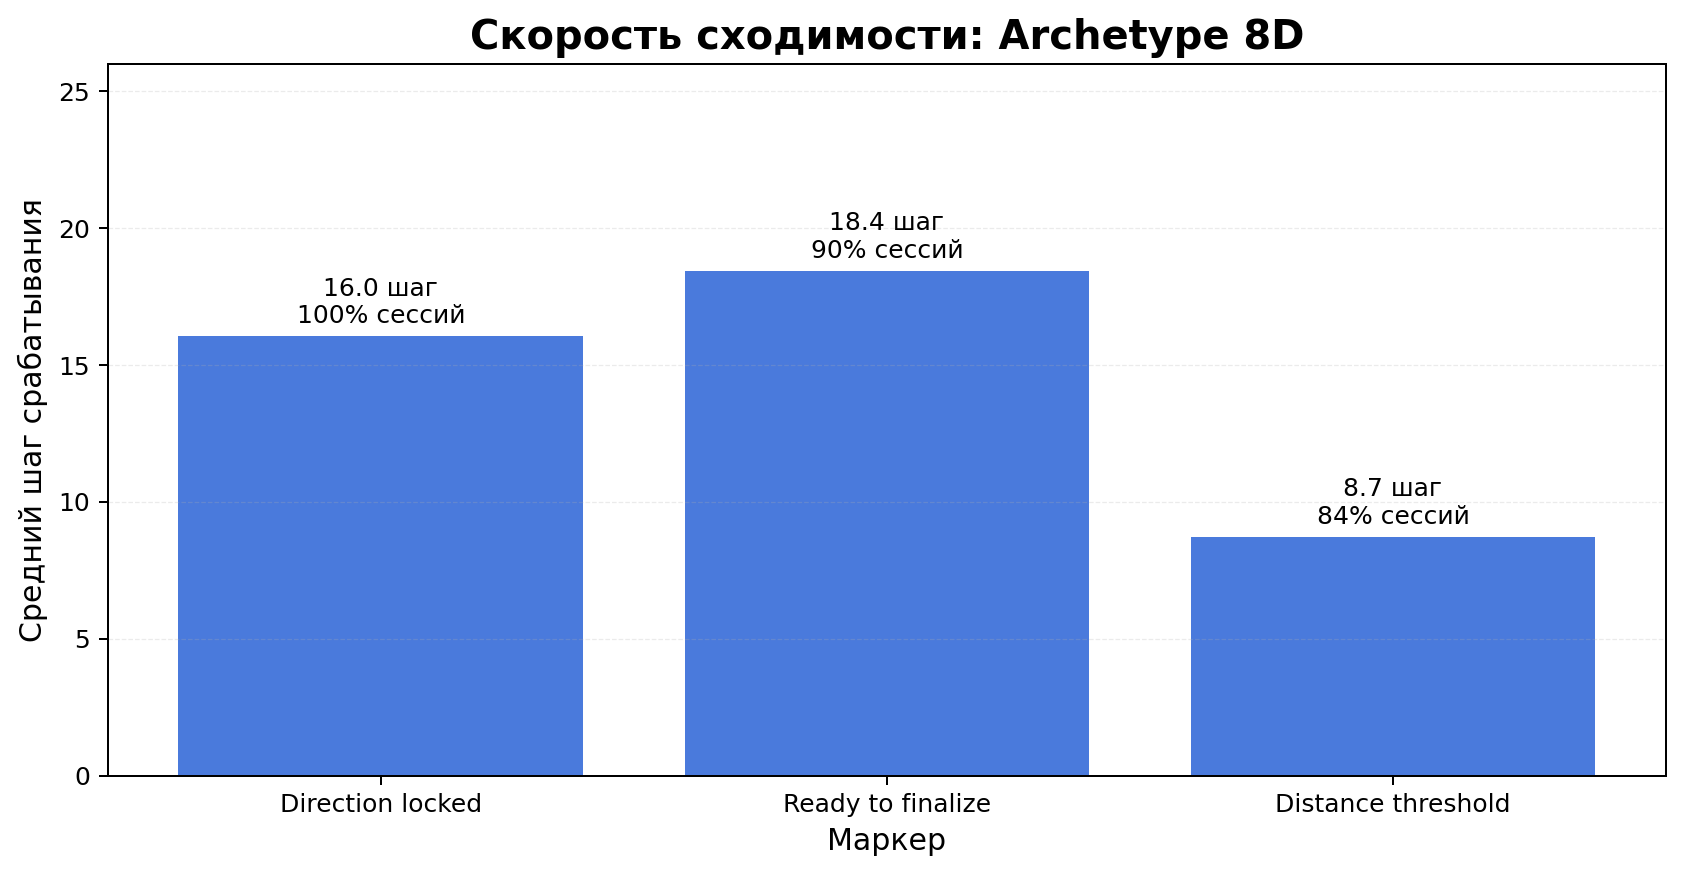

In [6]:
phase_plots.plot_convergence_speed(
    sessions_df,
    figures_dir / "article_phase_controller_convergence_speed_archetype8d.png",
)
display(Image(filename=str(figures_dir / "article_phase_controller_convergence_speed_archetype8d.png")))


## 6. Распределение статусов сессий

Этот график нужен, чтобы отличать настоящую сходимость от случаев плато или насыщения ограничениями.


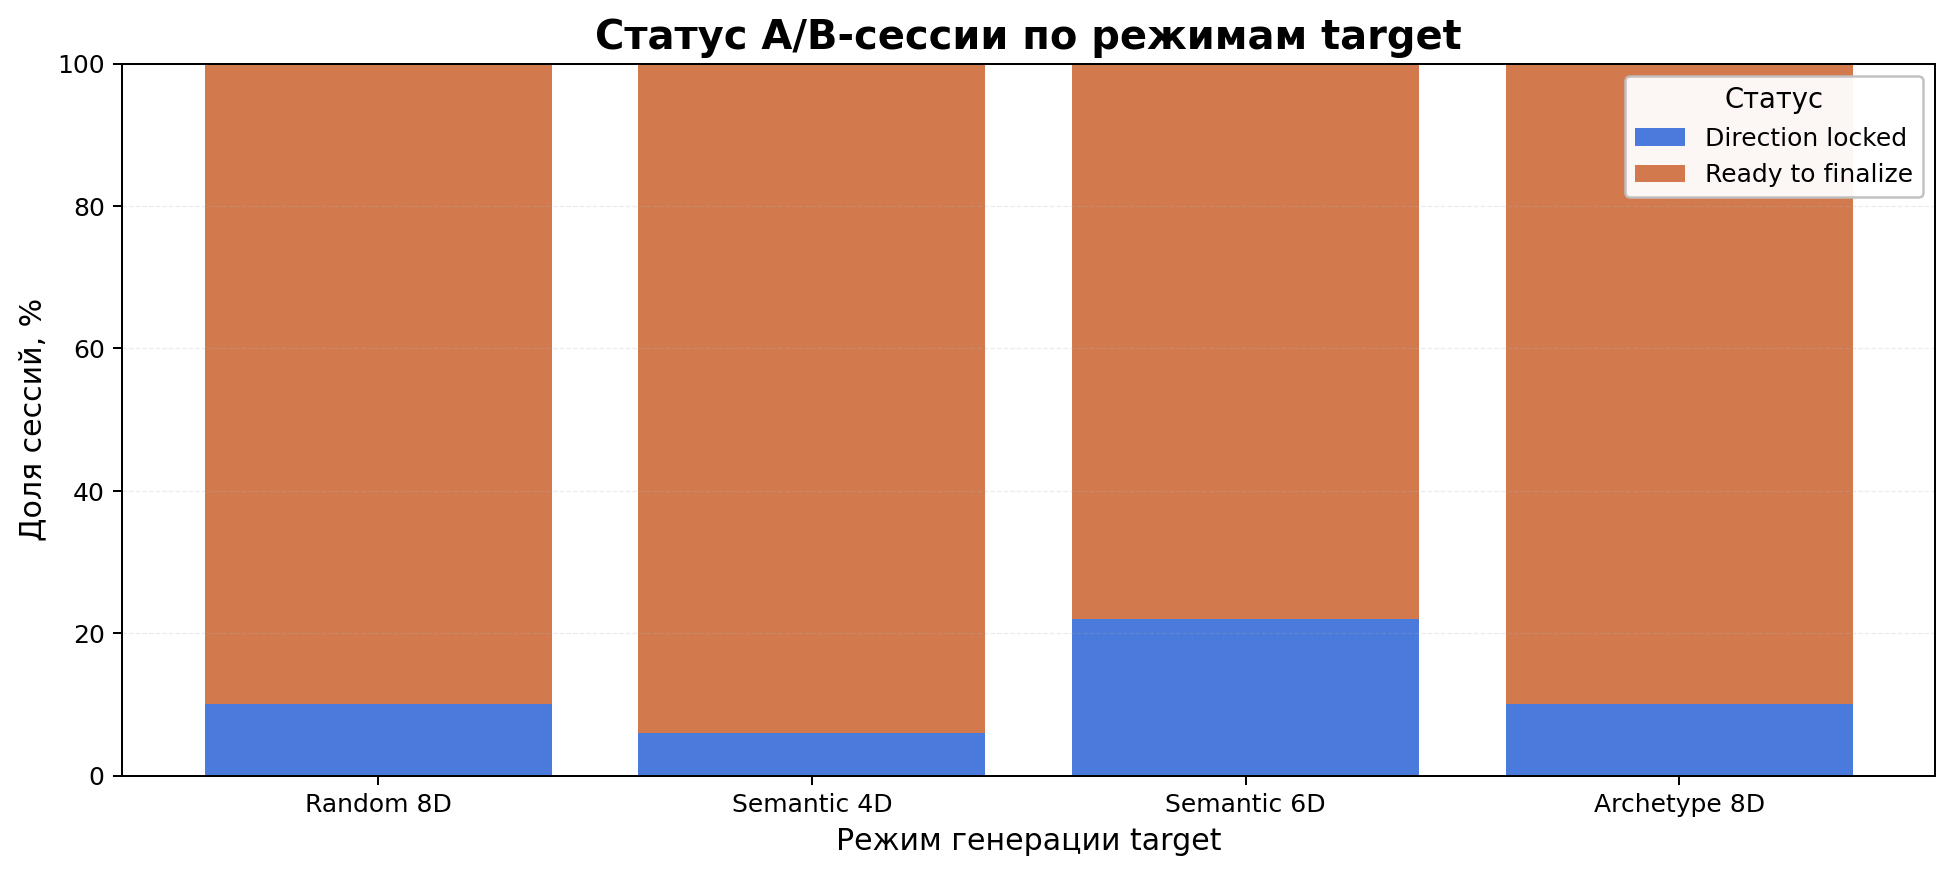

In [7]:
phase_plots.plot_status_distribution(
    sessions_df,
    figures_dir / "article_phase_controller_status_distribution.png",
)
display(Image(filename=str(figures_dir / "article_phase_controller_status_distribution.png")))


## 7. Использование фаз на Archetype 8D

Показывает, какую долю A/B-вопросов система провела в exploration и какую — в локальном zone refinement.


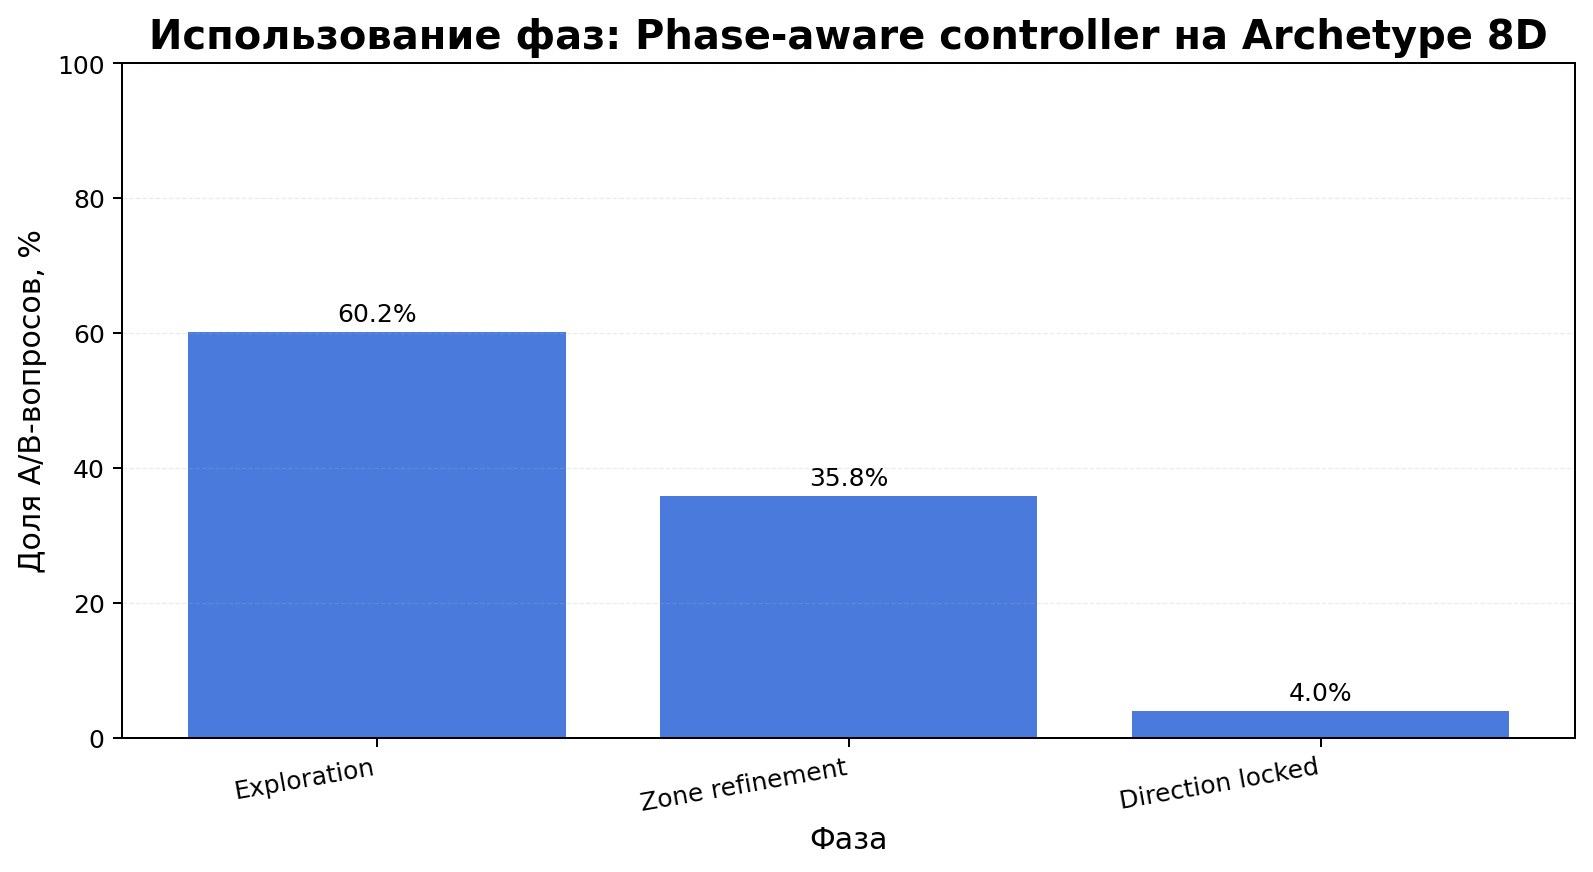

In [8]:
phase_plots.plot_phase_usage(
    steps_df,
    figures_dir / "article_phase_controller_phase_usage_archetype8d.png",
)
display(Image(filename=str(figures_dir / "article_phase_controller_phase_usage_archetype8d.png")))


## 8. Таблицы для статьи


In [9]:
sessions_df.to_csv(metrics_dir / "article_phase_controller_sessions.csv", index=False)
steps_df.to_csv(metrics_dir / "article_phase_controller_steps.csv", index=False)
statuses_df.to_csv(metrics_dir / "article_phase_controller_statuses.csv", index=False)
summary_df.to_csv(metrics_dir / "article_phase_controller_summary.csv", index=False)
summary_df.to_csv(tables_dir / "article_phase_controller_summary.csv", index=False)

summary_df


,target_mode,strategy,users,mean_heuristic_final_distance,mean_selected_blend_final_distance,mean_best_distance,mean_distance_auc,direction_lock_rate,ready_rate,synthetic_convergence_rate,saturation_rate,mean_direction_lock_step,mean_ready_step,mean_synthetic_threshold_step,mean_final_direction_confidence
0,archetype8d,phase_aware_v1,50,0.382190,0.362391,0.291288,0.591805,1.0,0.90,0.84,0.0,16.04,18.444444,8.714286,0.953317
1,archetype8d,semantic_active_v3_fixed,50,0.375143,0.358325,0.275170,0.592677,0.0,0.00,0.84,0.0,NaN,NaN,9.214286,0.964740
2,random8d,phase_aware_v1,50,1.378233,1.392761,1.352189,1.649199,1.0,0.90,0.00,0.0,16.02,19.288889,NaN,0.971483
3,random8d,semantic_active_v3_fixed,50,1.422696,1.429698,1.384561,1.659306,0.0,0.00,0.00,0.0,NaN,NaN,NaN,0.983611
4,semantic4d,phase_aware_v1,50,0.436302,0.435520,0.371626,0.852526,1.0,0.94,0.56,0.0,16.00,19.319149,12.107143,0.979727
5,semantic4d,semantic_active_v3_fixed,50,0.413593,0.409328,0.328845,0.854369,0.0,0.00,0.70,0.0,NaN,NaN,14.028571,0.984611
6,semantic6d,phase_aware_v1,50,0.617329,0.619230,0.551320,1.217329,1.0,0.78,0.42,0.0,16.00,20.076923,15.047619,0.983461
7,semantic6d,semantic_active_v3_fixed,50,0.531730,0.537860,0.483911,1.211080,0.0,0.00,0.58,0.0,NaN,NaN,16.586207,0.985971


## Вывод по phase-aware controller

Эксперимент с `Phase-aware controller` показал, что поверх основного `Semantic active v3` можно добавить слой мониторинга состояния A/B-сессии. Контроллер определяет фазы `exploration`, `direction_locked`, `zone_refinement` и `ready_to_finalize`, что позволяет оценивать не только итоговое расстояние до target, но и скорость сходимости personalization loop.

На режиме `Archetype 8D` система достигает synthetic distance threshold в среднем примерно к 9 шагу, однако внутренний proxy-маркер `ready_to_finalize` срабатывает позже — примерно к 18 шагу. Это ожидаемо, так как distance threshold использует скрытый synthetic target, недоступный в реальной системе, тогда как `ready_to_finalize` опирается только на внутренние признаки устойчивости сессии.

Сравнение `Semantic active v3 fixed` и `Phase-aware controller` показало, что фазовый контроллер почти не меняет итоговое качество: mean final distance остаётся на том же уровне. Это означает, что текущая версия phase-aware loop полезна прежде всего как слой диагностики и принятия решения о завершении сессии, но пока не даёт явного улучшения качества за счёт перехода к `zone_refinement`.

Таким образом, `Phase-aware controller` можно использовать как `Convergence Monitor`: он позволяет определить момент, когда система считает направление предпочтений найденным, и когда пользователю можно предложить сохранить профиль или пройти дополнительные уточняющие A/B-сравнения.